# Data Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Load Data

In [4]:
df = pd.read_csv('../data/raw/hour.csv')

print(f'Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(df.head())

Dataset: 17,379 rows, 17 columns
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


# 2. Target Value Stats: Total Rentals (cnt)

Hourly Rentals Statistics:
Average: 189 bikes/hour
Median: 142 bikes/hour
Max: 977 bikes/hour
Min: 1 bikes/hour


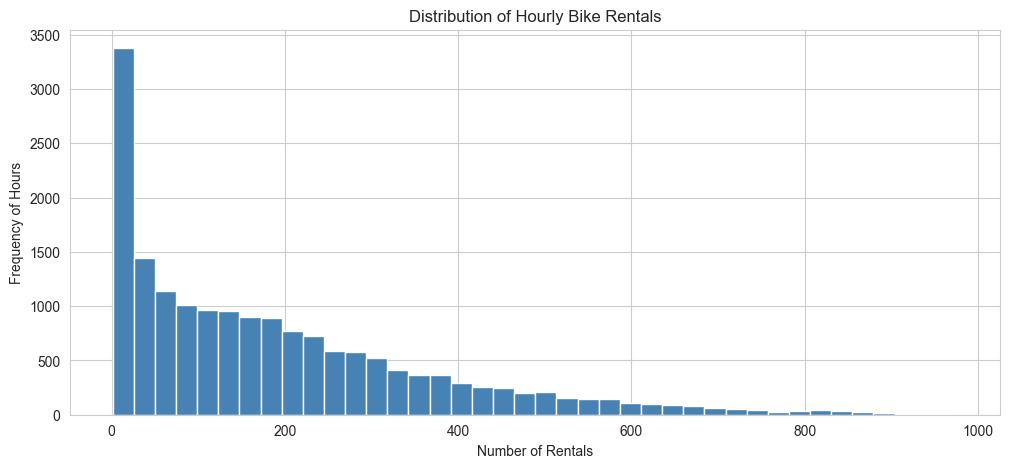

In [23]:
print('Hourly Rentals Statistics:')
print(f'Average: {df["cnt"].mean():.0f} bikes/hour')
print(f'Median: {df["cnt"].median():.0f} bikes/hour')
print(f'Max: {df["cnt"].max()} bikes/hour')
print(f'Min: {df["cnt"].min()} bikes/hour')

plt.hist(df['cnt'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Hourly Bike Rentals')
plt.xlabel('Number of Rentals')
plt.ylabel('Frequency of Hours')
plt.show()

# 3. Average Rentals by Hour of Day
How does demand change during the day?

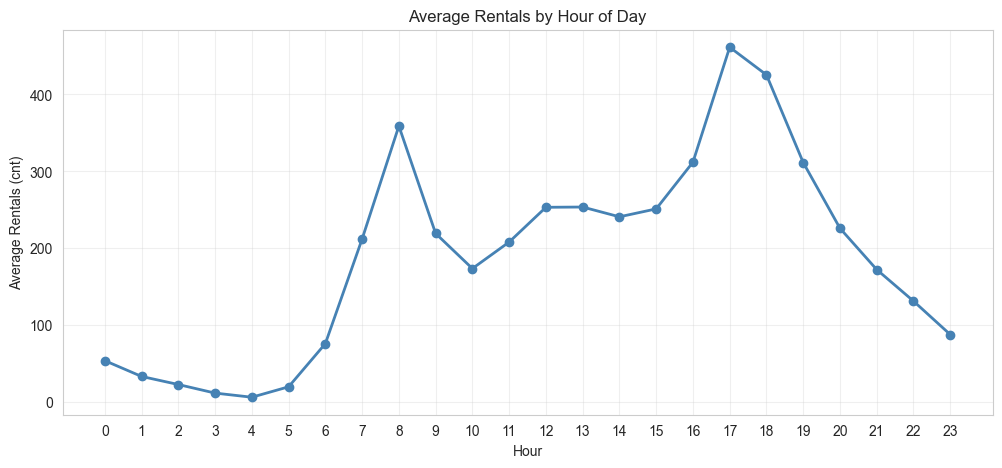

In [10]:
# Average rentals for each hour (0-23)
hourly = df.groupby('hr')['cnt'].mean()

plt.plot(hourly.index, hourly.values, marker='o', linewidth=2, color='steelblue')
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Rentals (cnt)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

# 4. Rentals By Temperature
How does temperature influence bike rental?

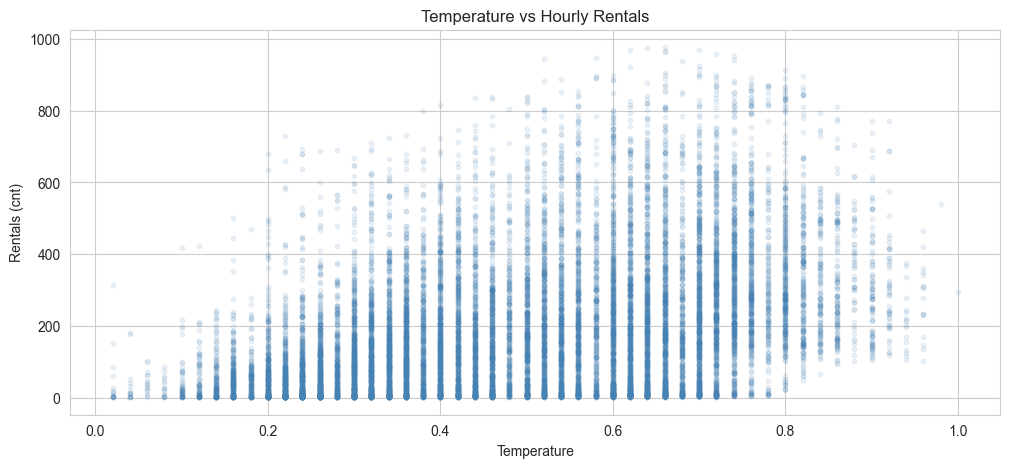

In [13]:
plt.scatter(df['temp'], df['cnt'], alpha=0.1, s=10, color='steelblue')
plt.title('Temperature vs Hourly Rentals')
plt.xlabel('Temperature')
plt.ylabel('Rentals (cnt)')
plt.show()

# 5. Working Days vs Weekends/Holidays
How people use bikes in weekdays compare to weekends and holidays?

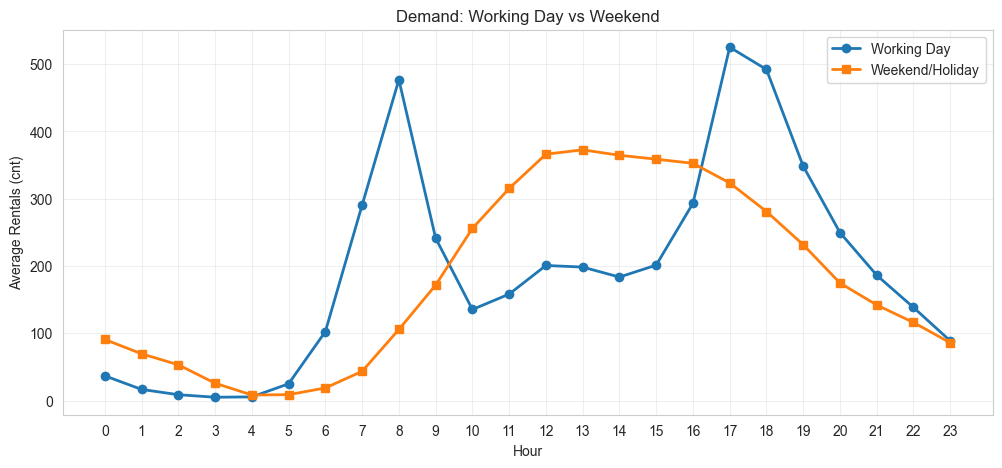

In [16]:
working = df[df['workingday'] == 1].groupby('hr')['cnt'].mean()
weekend = df[df['workingday'] == 0].groupby('hr')['cnt'].mean()

plt.plot(working.index, working.values, marker='o', label='Working Day', linewidth=2)
plt.plot(weekend.index, weekend.values, marker='s', label='Weekend/Holiday', linewidth=2)
plt.title('Demand: Working Day vs Weekend')
plt.xlabel('Hour')
plt.ylabel('Average Rentals (cnt)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Features Importance: Correlation Analysis

Which variables are most connected to rental demand?

- +1 = Perfect positive correlation (Variable ↑ and Target ↑)
- 0 = No correlation (No relationship between variable and target)
- -1 = Perfect negative correlation (Variable ↑ and Target ↓)

In [35]:
# Correlation with target variable
cols_to_check = ['cnt', 'hr', 'temp', 'atemp', 'hum', 'windspeed', 'season', 'weathersit', 'workingday']
corr = df[cols_to_check].corr()['cnt'].drop('cnt').sort_values(ascending=False)

print('Correlation with Rentals (cnt):')
print(corr.round(3))

Correlation with Rentals (cnt):
temp          0.405
atemp         0.401
hr            0.394
season        0.178
windspeed     0.093
workingday    0.030
weathersit   -0.142
hum          -0.323
Name: cnt, dtype: float64
